# **Project Name**    - Voyage Analytics : Integrating MLOps in Travel

##### **Project Type**    - MLOps (Productionization of ML Systems)
##### **Contribution**    - Individual
##### **Submitted by** -  Premsagar Palled


# **GitHub Link -** https://github.com/prem1555/Integrating_MLOps_in_Travel_Productionization_of_ML_Systems/tree/main

# **Project Summary -**

This project focuses on building an end-to-end travel analytics and MLOps pipeline using travel datasets.

The project includes:

1. Flight Price Prediction using Regression
2. Gender Classification Model
3. Hotel Recommendation System
4. REST API deployment using Flask
5. MLflow Experiment Tracking
6. Docker Containerization
7. Kubernetes Deployment
8. Workflow Automation using Apache Airflow
9. CI/CD using Jenkins
10. Interactive Dashboard using Streamlit

# **Problem Statement**


The ability to predict what the cost of travel will be to consumers and render personalized recommendations is key in improving customer satisfaction, cutting down operational efficiency. However, there are several challenges that the industry faces:

Price Stability: Flight prices price can vary due to demand, seasonality & economic conditions. There is an issue with travelers finding the perfect pricing of it and there are no really accurate systems in travel agencies to predict prices.

Personalized recommendations: In most case, travelers are only provided with unpersonalized travel advice which was not based on the traveler's history of preferences. All of this leads to a poor user experience and very little customer retention rates.

Poor Data Management and Deployment: Most travel companies do not have the facilities for efficient data management or deployment of machine learning models that operate at both a low latency plus high throughput levels.

# **General Guidelines** : -  
1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from datetime import datetime
import datetime as dt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import RandomizedSearchCV , cross_val_score, KFold

from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import log_loss

import scipy.stats as stats
import statsmodels.api as sm

from google.colab import drive

### Dataset Loading

In [3]:
# Mount Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Load Flights, Hotels and Users dataset
flights = pd.read_csv("/content/drive/MyDrive/flights (1).csv")
user = pd.read_csv("/content/drive/MyDrive/users (1).csv")
hotel = pd.read_csv("/content/drive/MyDrive/hotels.csv")

### Dataset First View

In [5]:
# Users Dataset First Look
user.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [6]:
# Hotel Dataset First Look
hotel.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [7]:
# Flights Dataset First Look
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


### Dataset Rows & Columns count

In [8]:
# Dataset Rows & Columns count
print("User Dataset Rows :",user.shape[0])
print("User Dataset Columns :",user.shape[1])

User Dataset Rows : 1340
User Dataset Columns : 5


In [9]:
# Dataset Rows & Columns count
print("Hotel Dataset Rows :",hotel.shape[0])
print("Hotel Dataset Columns :",hotel.shape[1])

Hotel Dataset Rows : 40552
Hotel Dataset Columns : 8


In [10]:
# Dataset Rows & Columns count
print("Flights Dataset Rows : ", flights.shape[0])
print("Flights Dataset Columns : ", flights.shape[1])

Flights Dataset Rows :  271888
Flights Dataset Columns :  10


### Dataset Information

In [11]:
# Dataset Info
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [12]:
# Dataset Info
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


In [13]:
# Dataset Info
hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


#### Duplicate Values

In [14]:
# Flights Dataset Duplicate Value Count
flights.duplicated().sum()

np.int64(0)

In [15]:
# Flights Dataset Duplicate Value Count
user.duplicated().sum()

np.int64(0)

In [16]:
# Flights Dataset Duplicate Value Count
hotel.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [17]:
# Missing Values/Null Values Count
flights.isnull().sum()

,0
travelCode,0
userCode,0
from,0
to,0
flightType,0
price,0
time,0
distance,0
agency,0
date,0


In [18]:
# Missing Values/Null Values Count
user.isnull().sum()

,0
code,0
company,0
name,0
gender,0
age,0


In [19]:
# Missing Values/Null Values Count
hotel.isnull().sum()

,0
travelCode,0
userCode,0
name,0
place,0
days,0
price,0
total,0
date,0


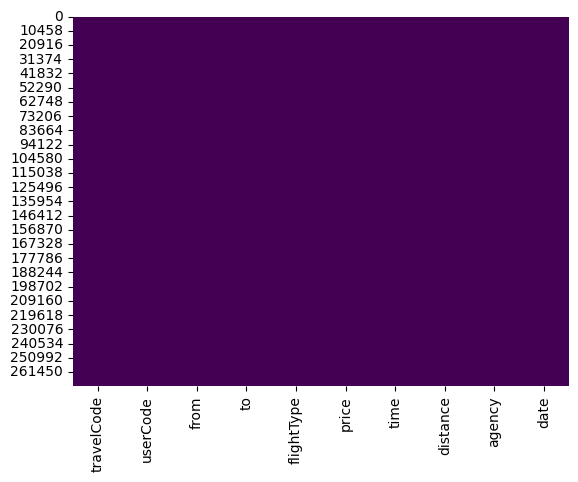

In [20]:
# Visualize missing values
sns.heatmap(flights.isnull(), cbar=False, cmap='viridis')
plt.show()

### What did you know about your dataset?

## ***2. Understanding Your Variables***

In [21]:
# Dataset Columns
flights.columns

Index(['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time',
       'distance', 'agency', 'date'],
      dtype='object')

In [22]:
# Dataset Columns
user.columns

Index(['code', 'company', 'name', 'gender', 'age'], dtype='object')

In [23]:
# Dataset Columns
hotel.columns

Index(['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total',
       'date'],
      dtype='object')

In [24]:
# Dataset Describe
flights.describe()

,travelCode,userCode,price,time,distance
count,271888.000000,271888.000000,271888.00000,271888.000000,271888.000000
mean,67971.500000,667.505495,957.37503,1.421147,546.955535
std,39243.724665,389.523127,362.31189,0.542541,208.851288
min,0.000000,0.000000,301.51000,0.440000,168.220000
25%,33985.750000,326.000000,672.66000,1.040000,401.660000
50%,67971.500000,659.000000,904.00000,1.460000,562.140000
75%,101957.250000,1011.000000,1222.24000,1.760000,676.530000
max,135943.000000,1339.000000,1754.17000,2.440000,937.770000


In [25]:
# Dataset Describe
user.describe()

,code,age
count,1340.000000,1340.000000
mean,669.500000,42.742537
std,386.968991,12.869779
min,0.000000,21.000000
25%,334.750000,32.000000
50%,669.500000,42.000000
75%,1004.250000,54.000000
max,1339.000000,65.000000


In [26]:
# Dataset Describe
hotel.describe()

,travelCode,userCode,days,price,total
count,40552.000000,40552.000000,40552.000000,40552.000000,40552.000000
mean,67911.794461,666.963726,2.499679,214.439554,536.229513
std,39408.199333,391.136794,1.119326,76.742305,319.331482
min,0.000000,0.000000,1.000000,60.390000,60.390000
25%,33696.750000,323.000000,1.000000,165.990000,247.620000
50%,67831.000000,658.000000,2.000000,242.880000,495.240000
75%,102211.250000,1013.000000,4.000000,263.410000,742.860000
max,135942.000000,1339.000000,4.000000,313.020000,1252.080000


### Variables Description

#### Voyage Analytics Datasets

#### **Flights Dataset**
- travelCode : Unique travel transaction ID.
- userCode : Links users and travel data.
- from : Flight origin feature.
- to : Destination feature.
- flightType : Flight category.
- price : Target variable for regression model.
- time : Predictor variable.
- distance : Important predictor for price estimation.
- agency : Airline/travel agency information.
- date : Used for feature engineering (year, month, day).

#### **Hotels Dataset**
- travelCode : Travel booking ID.
- userCode : Links hotel and user datasets.
- name : Hotel identifier used in recommendation engine.
- place : Hotel location feature.
- days : Stay duration.
- price : Cost per day.
- total : Total spending.
- date : Booking date.

#### **Users Dataset**
- code : Used as unique user identifier and for joining datasets.
- company : Used in gender classification model.
- name : User attribute used in classification preprocessing.
- gender : Target variable for classification model.
- age : Numerical feature used in classification.


### Check Unique Values for each variable.

In [27]:
# Check Unique Values for each variable.
for i in list(flights.columns):
  print(f'{i} : {flights[i].nunique()}')

travelCode : 135944
userCode : 1335
from : 9
to : 9
flightType : 3
price : 490
time : 33
distance : 35
agency : 3
date : 999


In [28]:
# Check Unique Values for each variable.
for i in list(user.columns):
  print(f'{i} : {user[i].nunique()}')

code : 1340
company : 5
name : 1338
gender : 3
age : 45


In [29]:
# Check Unique Values for each variable.
for i in list(hotel.columns):
  print(f'{i} : {hotel[i].nunique()}')

travelCode : 40552
userCode : 1310
name : 9
place : 9
days : 4
price : 9
total : 36
date : 199


## 3. ***Data Wrangling***

### Data Wrangling Code

In [47]:
# Rename the column
user.rename(columns={'id':'userCode','name':'user_name'},inplace=True)

In [31]:
# Rename the column
hotel.rename(columns={'name':'hotel_name','price':'hotel_price','date':'hotel_date'},inplace=True)

### What all manipulations have you done and insights you found?

- Renamed the name column in users dataset.
- Renamed the name, price, date column in hotel dataset.
- Merged all the datasets for further analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

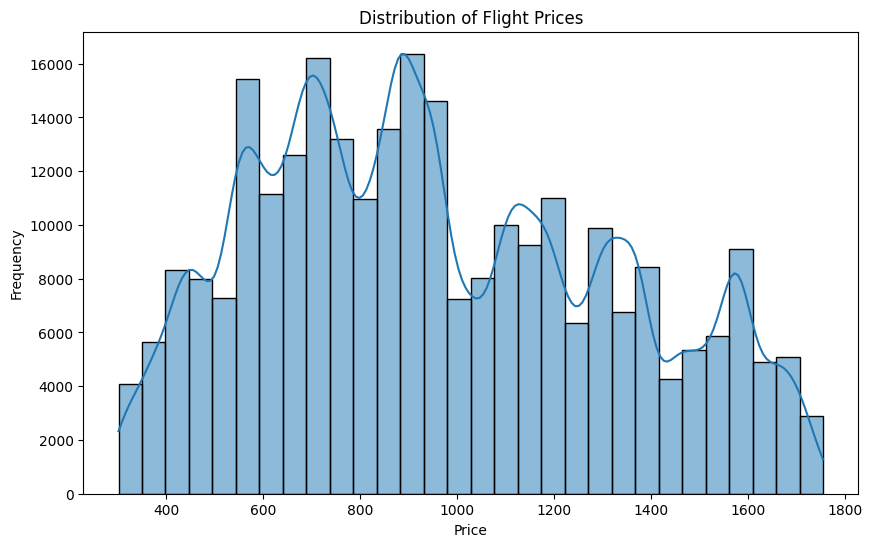

In [32]:
# Chart - 1 (Distribution of Flight Prices)
plt.figure(figsize=(10, 6))
sns.histplot(flights['price'], kde=True, bins=30)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

* I picked a histogram with a KDE (Kernel Density Estimate) overlay to visualize the distribution of flight prices. This chart effectively shows the frequency of different price ranges and provides a smooth estimate of the underlying distribution.

* The chart reveals the distribution of flight prices, highlighting the most common price ranges and indicating how prices are spread out.

* It can help identify peaks (most frequent prices) and the overall variability in flight prices.

* I picked a histogram with a KDE (Kernel Density Estimate) overlay to visualize the distribution of flight prices. This chart effectively shows the frequency of different price ranges and provides a smooth estimate of the underlying distribution.

##### 2. What is/are the insight(s) found from the chart?

* The chart reveals the distribution of flight prices, highlighting the most common price ranges and indicating how prices are spread out.

* It can help identify peaks (most frequent prices) and the overall variability in flight prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 2

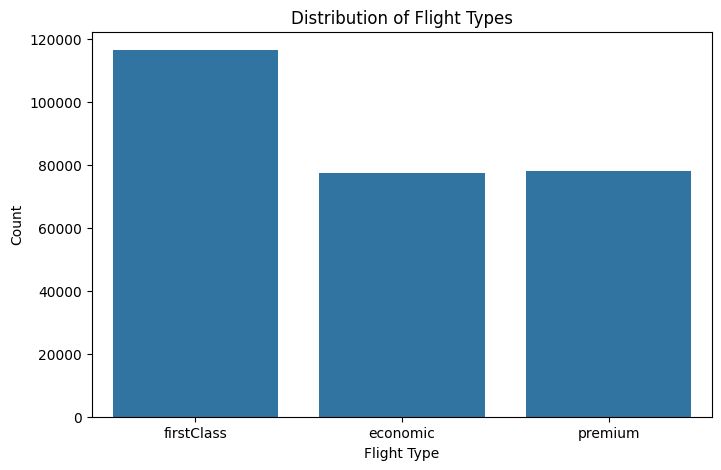

In [33]:
# Chart - 2 (Distribution of Flight Types)
plt.figure(figsize=(8, 5))
sns.countplot(data=flights, x='flightType')
plt.title('Distribution of Flight Types')
plt.xlabel('Flight Type')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is ideal for showing the frequency distribution of categorical variables like flight types.

2. What is/are the insight(s) found from the chart?



*   The chart reveals the most and least common flight types, providing insights into customer preferences.

*  Most of the People choose firstClass over economic and premium



3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.



*   Yes, knowing popular flight types can help in optimizing service offerings and marketing strategies.





Chart - 3


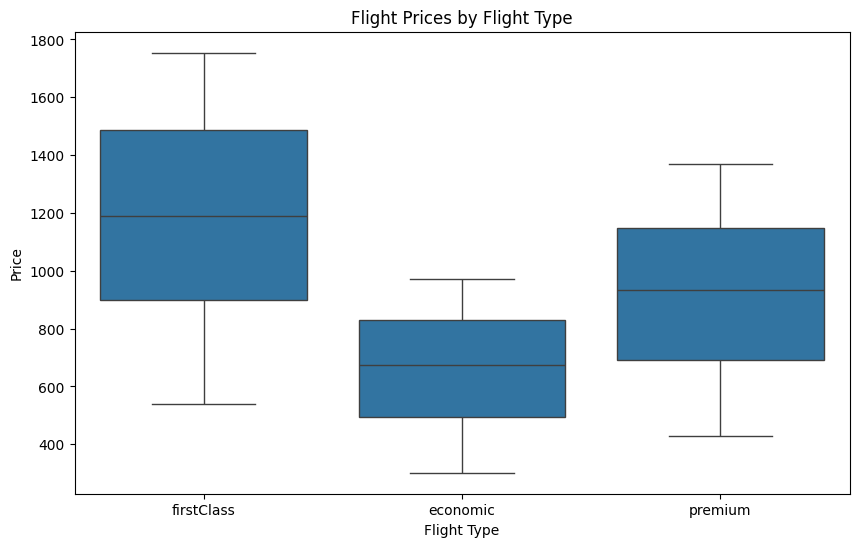

In [34]:
# Chart - 3 (Flight Prices by Flight Type)
plt.figure(figsize=(10, 6))
sns.boxplot(data=flights, x='flightType', y='price')
plt.title('Flight Prices by Flight Type')
plt.xlabel('Flight Type')
plt.ylabel('Price')
plt.show()

##### 1. Why did you pick the specific chart?

Box plots are effective for comparing the distribution of a numerical variable across different categories.

##### 2. What is/are the insight(s) found from the chart?

There are significant differences in price distributions across different flight types, with firstClass flight types being consistently more expensive than premium and ecomic .

Yes, this information can help in pricing strategy and service differentiation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 4

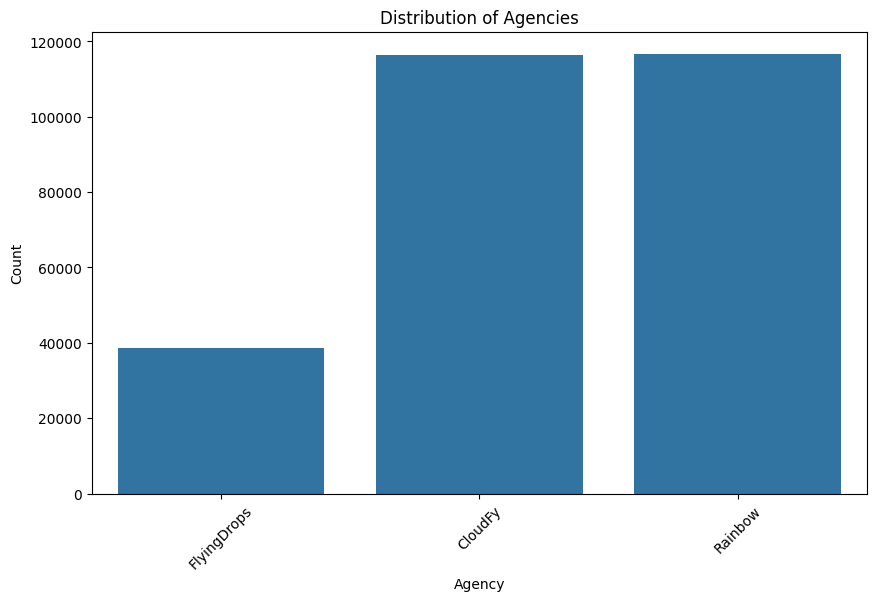

In [35]:
# Chart - 4 (Distribution of Agencies)
plt.figure(figsize=(10, 6))
sns.countplot(data=flights, x='agency')
plt.title('Distribution of Agencies')
plt.xlabel('Agency')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is suitable for showing the frequency distribution of categorical variables like agencies.

##### 2. What is/are the insight(s) found from the chart?

The chart shows which agencies are most active in the market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, understanding agency activity can help in strategic partnerships and market positioning.

#### Chart - 5

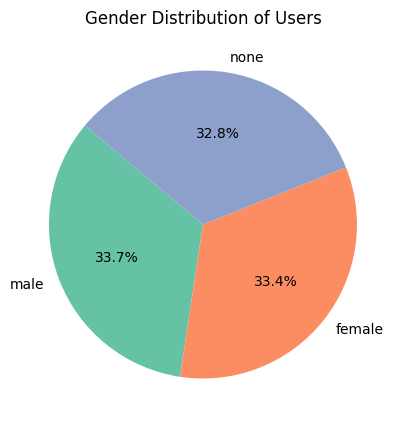

In [36]:
# Chart - 5 (Count the occurrences of each gender category)
gender_counts = user['gender'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 5))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62', '#8da0cb'], startangle=140)
plt.title("Gender Distribution of Users")
plt.show()

##### 1. Why did you pick the specific chart?

Pie charts makes it easier to compare absolute counts than a pie chart.

##### 2. What is/are the insight(s) found from the chart?

The charts reveals that dataset is balanced but there is problem that 32.8 % values are None that means we don't know the value of gender over here.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this can help in negotiating with agencies and understanding market dynamics.

#### Chart - 6

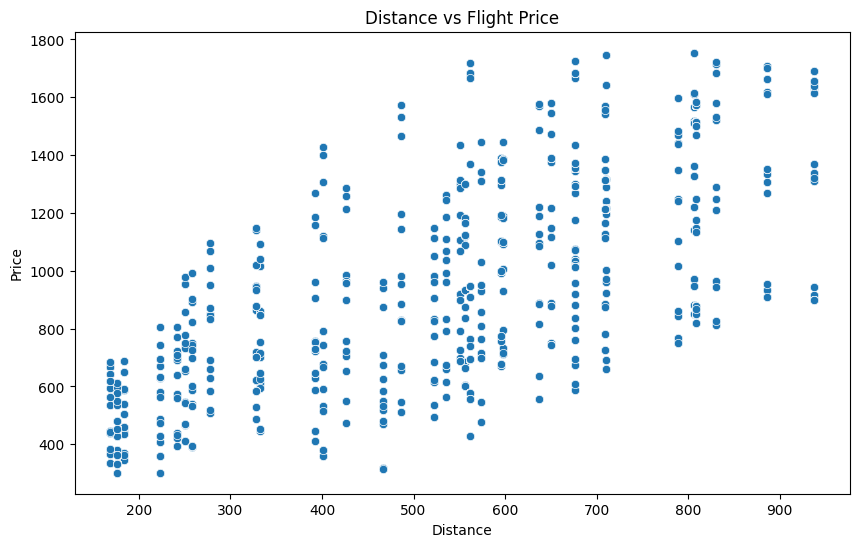

In [37]:
# Chart - 6 (Distance vs Flight Price)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=flights, x='distance', y='price')
plt.title('Distance vs Flight Price')
plt.xlabel('Distance')
plt.ylabel('Price')
plt.show()

##### 1. Why did you pick the specific chart?

Scatter plots are effective for visualizing relationships between two numerical variables.

##### 2. What is/are the insight(s) found from the chart?

There appears to be a positive correlation between distance and price, indicating that longer flights tend to be more expensive.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help in pricing flights based on distance and understanding cost drivers.

#### Chart - 7

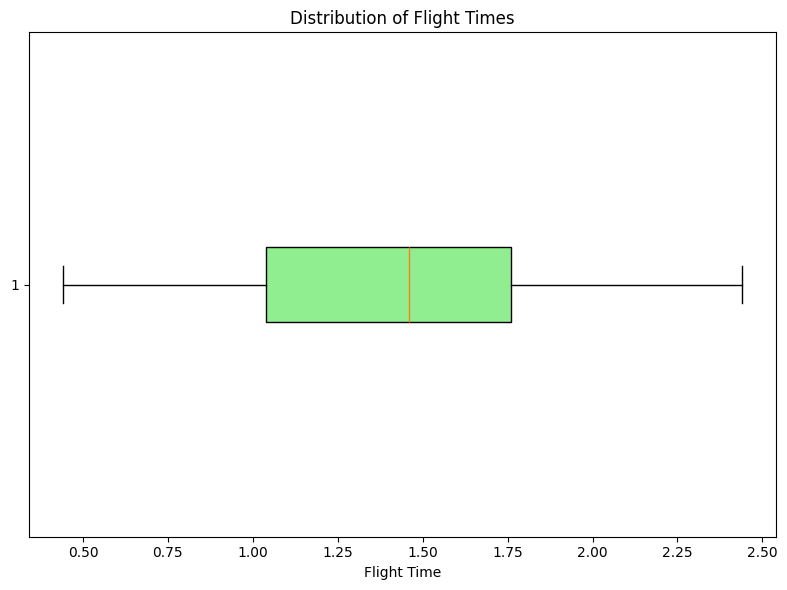

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.boxplot(
    flights['time'].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen')
)

plt.xlabel('Flight Time')
plt.title('Distribution of Flight Times')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is useful for displaying the distribution of a numerical variable, especially for identifying outliers. It shows the median, quartiles, and potential outliers in the data.

##### 2. What is/are the insight(s) found from the chart?

The box plot of flight times shows the median flight time and the interquartile range. There are a few potential outliers (points beyond the whiskers) indicating unusually long flight times. This could be investigated further. Most flight times seem to fall within a specific range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive: Manage customer expectations regarding flight durations and improve scheduling efficiency.
- Negative: Outliers (very long flights) could be due to delays or specific routes, and these should be addressed to improve customer satisfaction.
- Positive: Consider offering different flight options with varying durations to cater to customer preferences.

#### Chart - 8

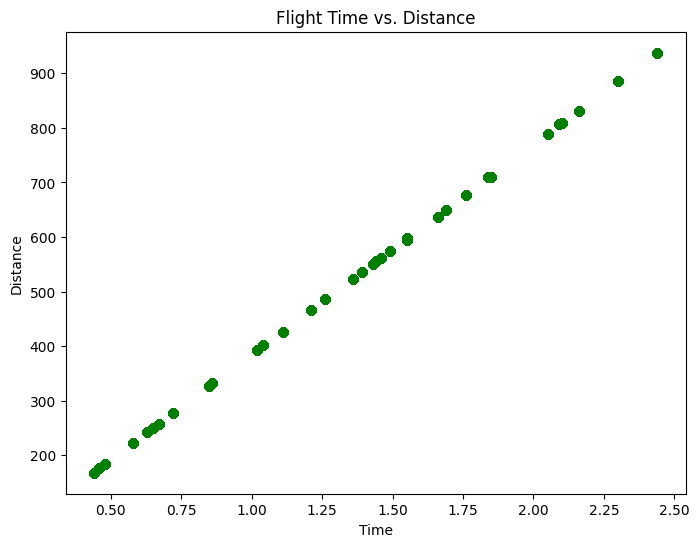

In [39]:
# Chart - 8 visualization code
plt.figure(figsize=(8, 6))
plt.scatter(flights['time'], flights['distance'], color='green', alpha=0.6)
plt.xlabel('Time')
plt.ylabel('Distance')
plt.title('Flight Time vs. Distance')
plt.savefig('chart6.png')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for visualizing the correlation between two continuous numerical variables (Time and Distance).

##### 2. What is/are the insight(s) found from the chart?

- There is a strong positive linear correlation between Flight Time and Distance.
- The data points align closely, indicating a consistent relationship (possibly a constant speed assumption).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps in predicting flight distance based on time.

#### Chart - 9

/tmp/ipykernel_2140/1301600549.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_hotel_price.values, y=avg_hotel_price.index, palette="viridis")


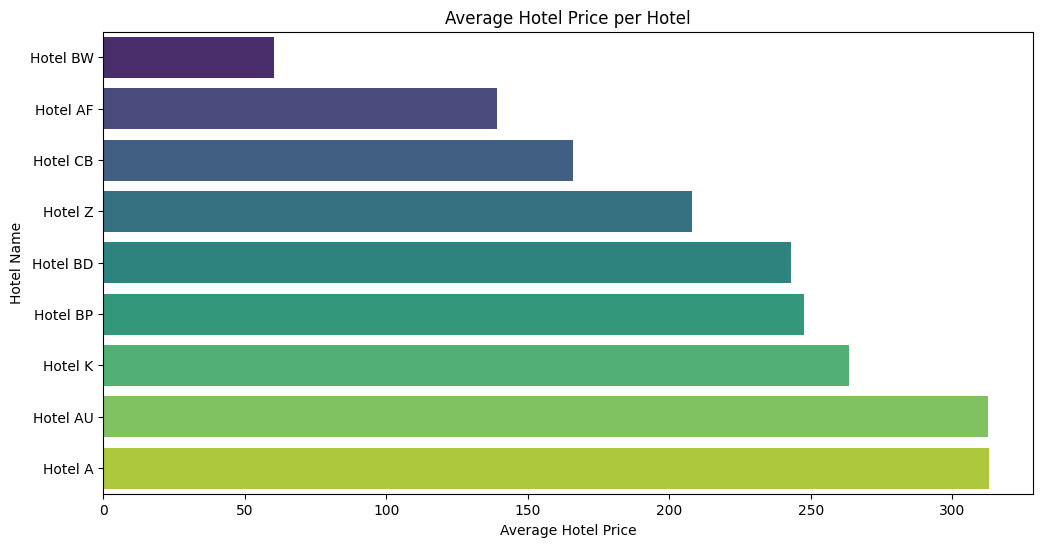

In [40]:
# Chart - 9 visualization code
plt.figure(figsize=(12, 6))
avg_hotel_price = hotel.groupby("hotel_name")["hotel_price"].mean().sort_values()
sns.barplot(x=avg_hotel_price.values, y=avg_hotel_price.index, palette="viridis")
plt.xlabel("Average Hotel Price")
plt.ylabel("Hotel Name")
plt.title("Average Hotel Price per Hotel")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was chosen because it effectively displays categorical data (hotel names) against a continuous variable (average hotel price). This makes it easy to compare hotel prices visually, especially when dealing with long hotel names, which are better represented horizontally.

##### 2. What is/are the insight(s) found from the chart?

- Hotel BW is the cheapest: It has the lowest average price, which could indicate budget-friendly accommodations.
- Hotels AU and A are the most expensive: They may offer premium services or target high-end customers.
- Mid-range hotels: The majority of hotels fall within a middle price bracket, which could indicate competitive pricing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help in pricing strategy, marketing, and customer targeting.

**Positive Impact:**

- Hotels with higher prices can justify their premium rates by offering exclusive services.
- Budget-friendly hotels can attract price-sensitive customers.
Mid-range hotels can focus on promotions to gain a competitive edge.

**Negative Growth Concerns:**

- If high-priced hotels fail to provide matching value, customers may switch to competitors.
- If low-priced hotels struggle with profitability, they may need to adjust pricing or cut costs.
- Understanding demand elasticity is crucial to avoid pricing mismatches that could reduce bookings.

#### Chart - 10

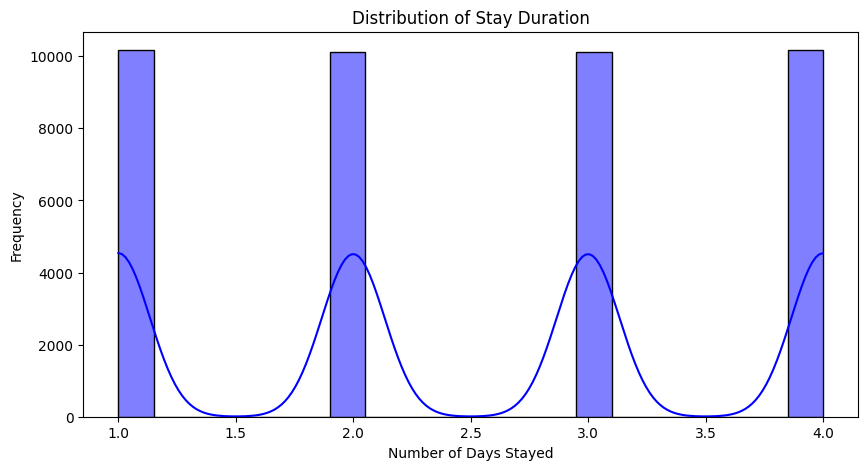

In [41]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(hotel["days"], bins=20, kde=True, color="blue")
plt.xlabel("Number of Days Stayed")
plt.ylabel("Frequency")
plt.title("Distribution of Stay Duration")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE plot was selected because it effectively visualizes the frequency distribution of stay durations. The histogram shows the exact counts for each stay duration, while the KDE smooths the distribution, making trends easier to observe.

##### 2. What is/are the insight(s) found from the chart?

- Stay durations are highly discrete: The data is concentrated at specific whole numbers (1, 2, 3, and 4 days), with no fractional values.
- Even distribution among durations: Each of these four durations has a similar frequency, meaning customers tend to book for these specific time frames.
- Gaps between bars: Indicates that people do not stay for durations like 1.5, 2.5, or 3.5 days, which suggests fixed hotel booking policies (e.g., full-day charges).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help in optimizing pricing strategies, promotions, and operational planning.

**Positive Impact:**

- Hotels can offer discounts for longer stays if they want to encourage customers to stay beyond the common durations.
- Hotels can optimize room availability by prioritizing bookings of 1 to 4 days to maximize occupancy.
- Special offers can be introduced for less popular durations to balance demand.

**Negative Growth Concerns:**

- If a hotel relies on longer stays, they might face occupancy gaps due to the preference for shorter stays.
- Fixed-duration stays could limit flexibility, leading some customers to choose alternative accommodations that offer hourly or half-day pricing.

#### Chart - 11

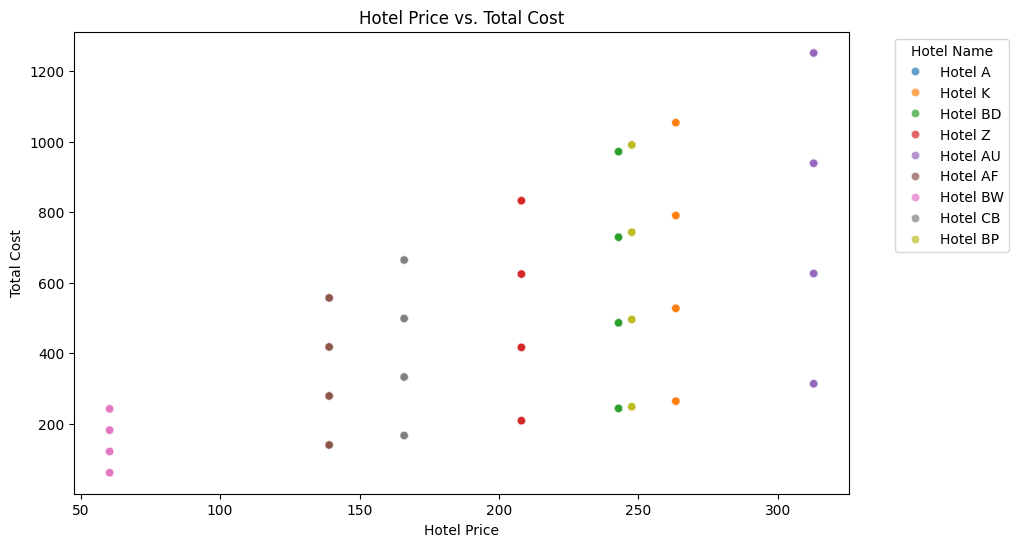

In [42]:
# Chart - 11 (Hotel Price vs. Total Cost)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=hotel["hotel_price"], y=hotel["total"], hue=hotel["hotel_name"], palette="tab10", alpha=0.7)
plt.xlabel("Hotel Price")
plt.ylabel("Total Cost")
plt.title("Hotel Price vs. Total Cost")
plt.legend(title="Hotel Name", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

##### 1. Why did you pick the specific chart?

*A* **scatter plot** helps visualize the relationship between **Hotel Price** and **Total Cost**, showing trends across different hotels.

##### 2. What is/are the insight(s) found from the chart?

- Higher hotel prices generally lead to higher total costs, indicating longer stays.
- Popular price points (e.g., 150, 250, 300) suggest strategic pricing opportunities.
- Variability in total cost shows differences in stay duration and booking patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Optimizing pricing strategies, offering extended-stay discounts, and targeting high-value customers.

**Negative:** High-priced hotels with short stays may struggle with retention; low-priced long stays may strain resources.

#### Chart - 12

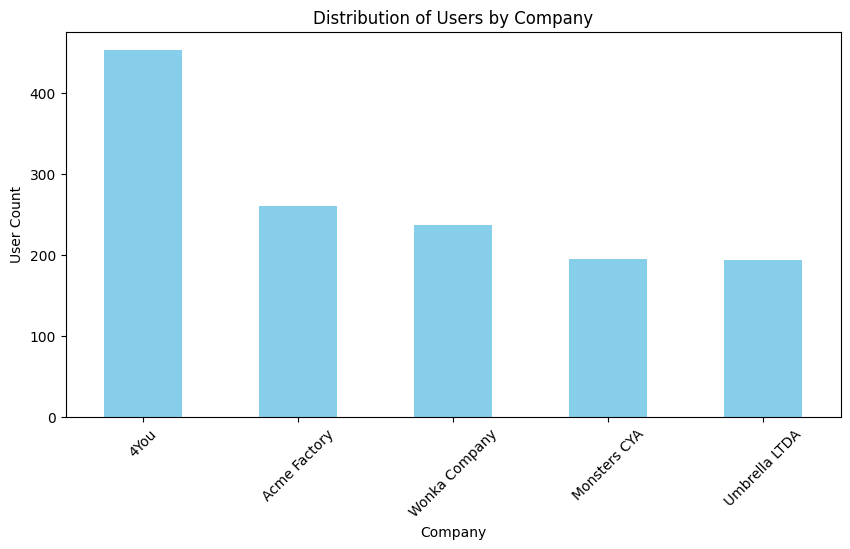

In [43]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 5))
user['company'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribution of Users by Company")
plt.xlabel("Company")
plt.ylabel("User Count")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing categorical data, such as the number of users per company. It provides a clear visual representation of how users are distributed across different companies, making it easy to identify the company with the highest and lowest number of users.

##### 2. What is/are the insight(s) found from the chart?

- The company "4You" has the highest number of users, significantly more than the others.
- Companies like "Monsters CYA" and "Umbrella LTDA" have relatively fewer users.
- The distribution suggests that some companies are attracting more users than others, possibly due to better services, brand reputation, or market presence.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help businesses in multiple ways:

- Companies with higher user counts can analyze what they are doing well (pricing, customer satisfaction, brand loyalty) and continue optimizing their strategies.

- A company has a significantly lower number of users, it may indicate customer dissatisfaction, weak market reach, or ineffective business strategies.

#### Chart - 13

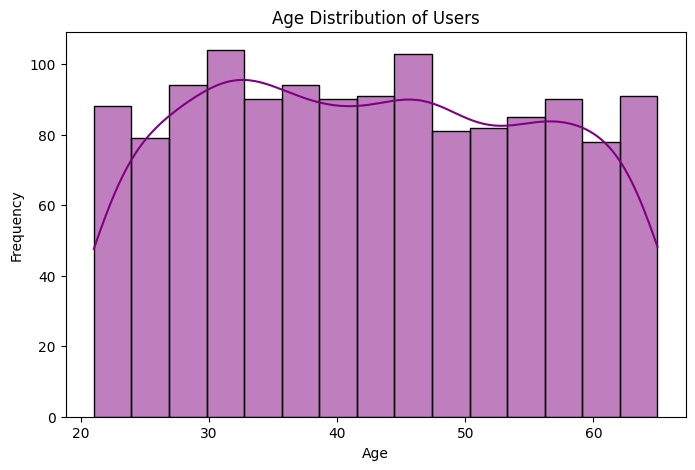

In [44]:
# Chart - 13 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(user['age'], bins=15, kde=True, color='purple')
plt.title("Age Distribution of Users")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the best choice for visualizing the distribution of a continuous variable like age. It helps identify the spread, concentration, and possible skewness of user demographics. The KDE line adds a smooth curve to show the general trend in user age distribution.

##### 2. What is/are the insight(s) found from the chart?

- Users are spread across different age groups, but there are peaks in certain age ranges, particularly around 30-35 and 50-55 years.
- There is no extreme skewness, indicating a fairly balanced user base.
- The drop in frequency at the youngest and oldest age groups suggests fewer users in these categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help businesses in various ways:

- Targeted Marketing: If most users fall within 30-55 years, businesses can focus on products and marketing strategies tailored to this demographic.

- If a company relies on younger users but the data shows fewer in the 20-25 age range, it could indicate a problem with branding, accessibility, or relevance for younger audiences.

#### Chart - 14 - Correlation Heatmap

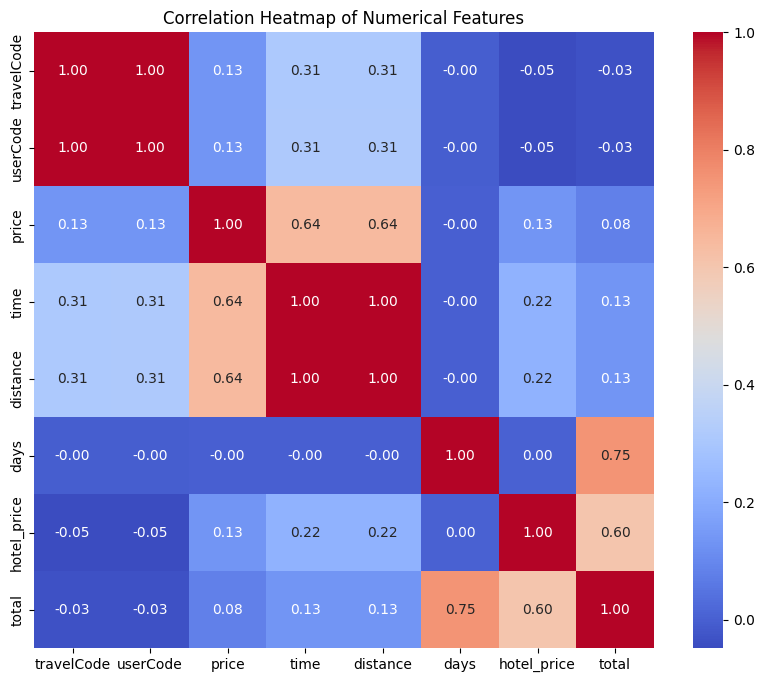

In [48]:
# Correlation Heatmap visualization code

import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df'
numerical_cols = merged_data.select_dtypes(include=['number']).columns
correlation_matrix = merged_data[numerical_cols].corr()

plt.figure(figsize=(10, 8))  # Adjust figure size if needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen because it visually represents the relationships between multiple numerical variables in a single view. This is particularly useful when analyzing large datasets, as it allows us to quickly identify strong or weak correlations between features.

##### 2. What is/are the insight(s) found from the chart?

**Strong Correlations:**

- **Days vs. Total (0.75):** The total cost is highly correlated with the number of days, which makes sense as longer stays increase expenses.
- **Hotel Price vs. Total (0.60):** Hotel prices have a significant impact on the total expenditure.
- **Price vs. Time & Distance (0.64):** The cost is influenced by both travel time and distance, suggesting longer trips cost more.
Weak or No Correlation:
- **Age vs. Any Feature:** Age does not significantly impact travel costs, time, or any other major feature, meaning user age does not drive pricing decisions.
- **User Code vs. Financial Factors:** The unique identifier for users does not affect price, time, or total spending.

#### Chart - 15 - Pair Plot

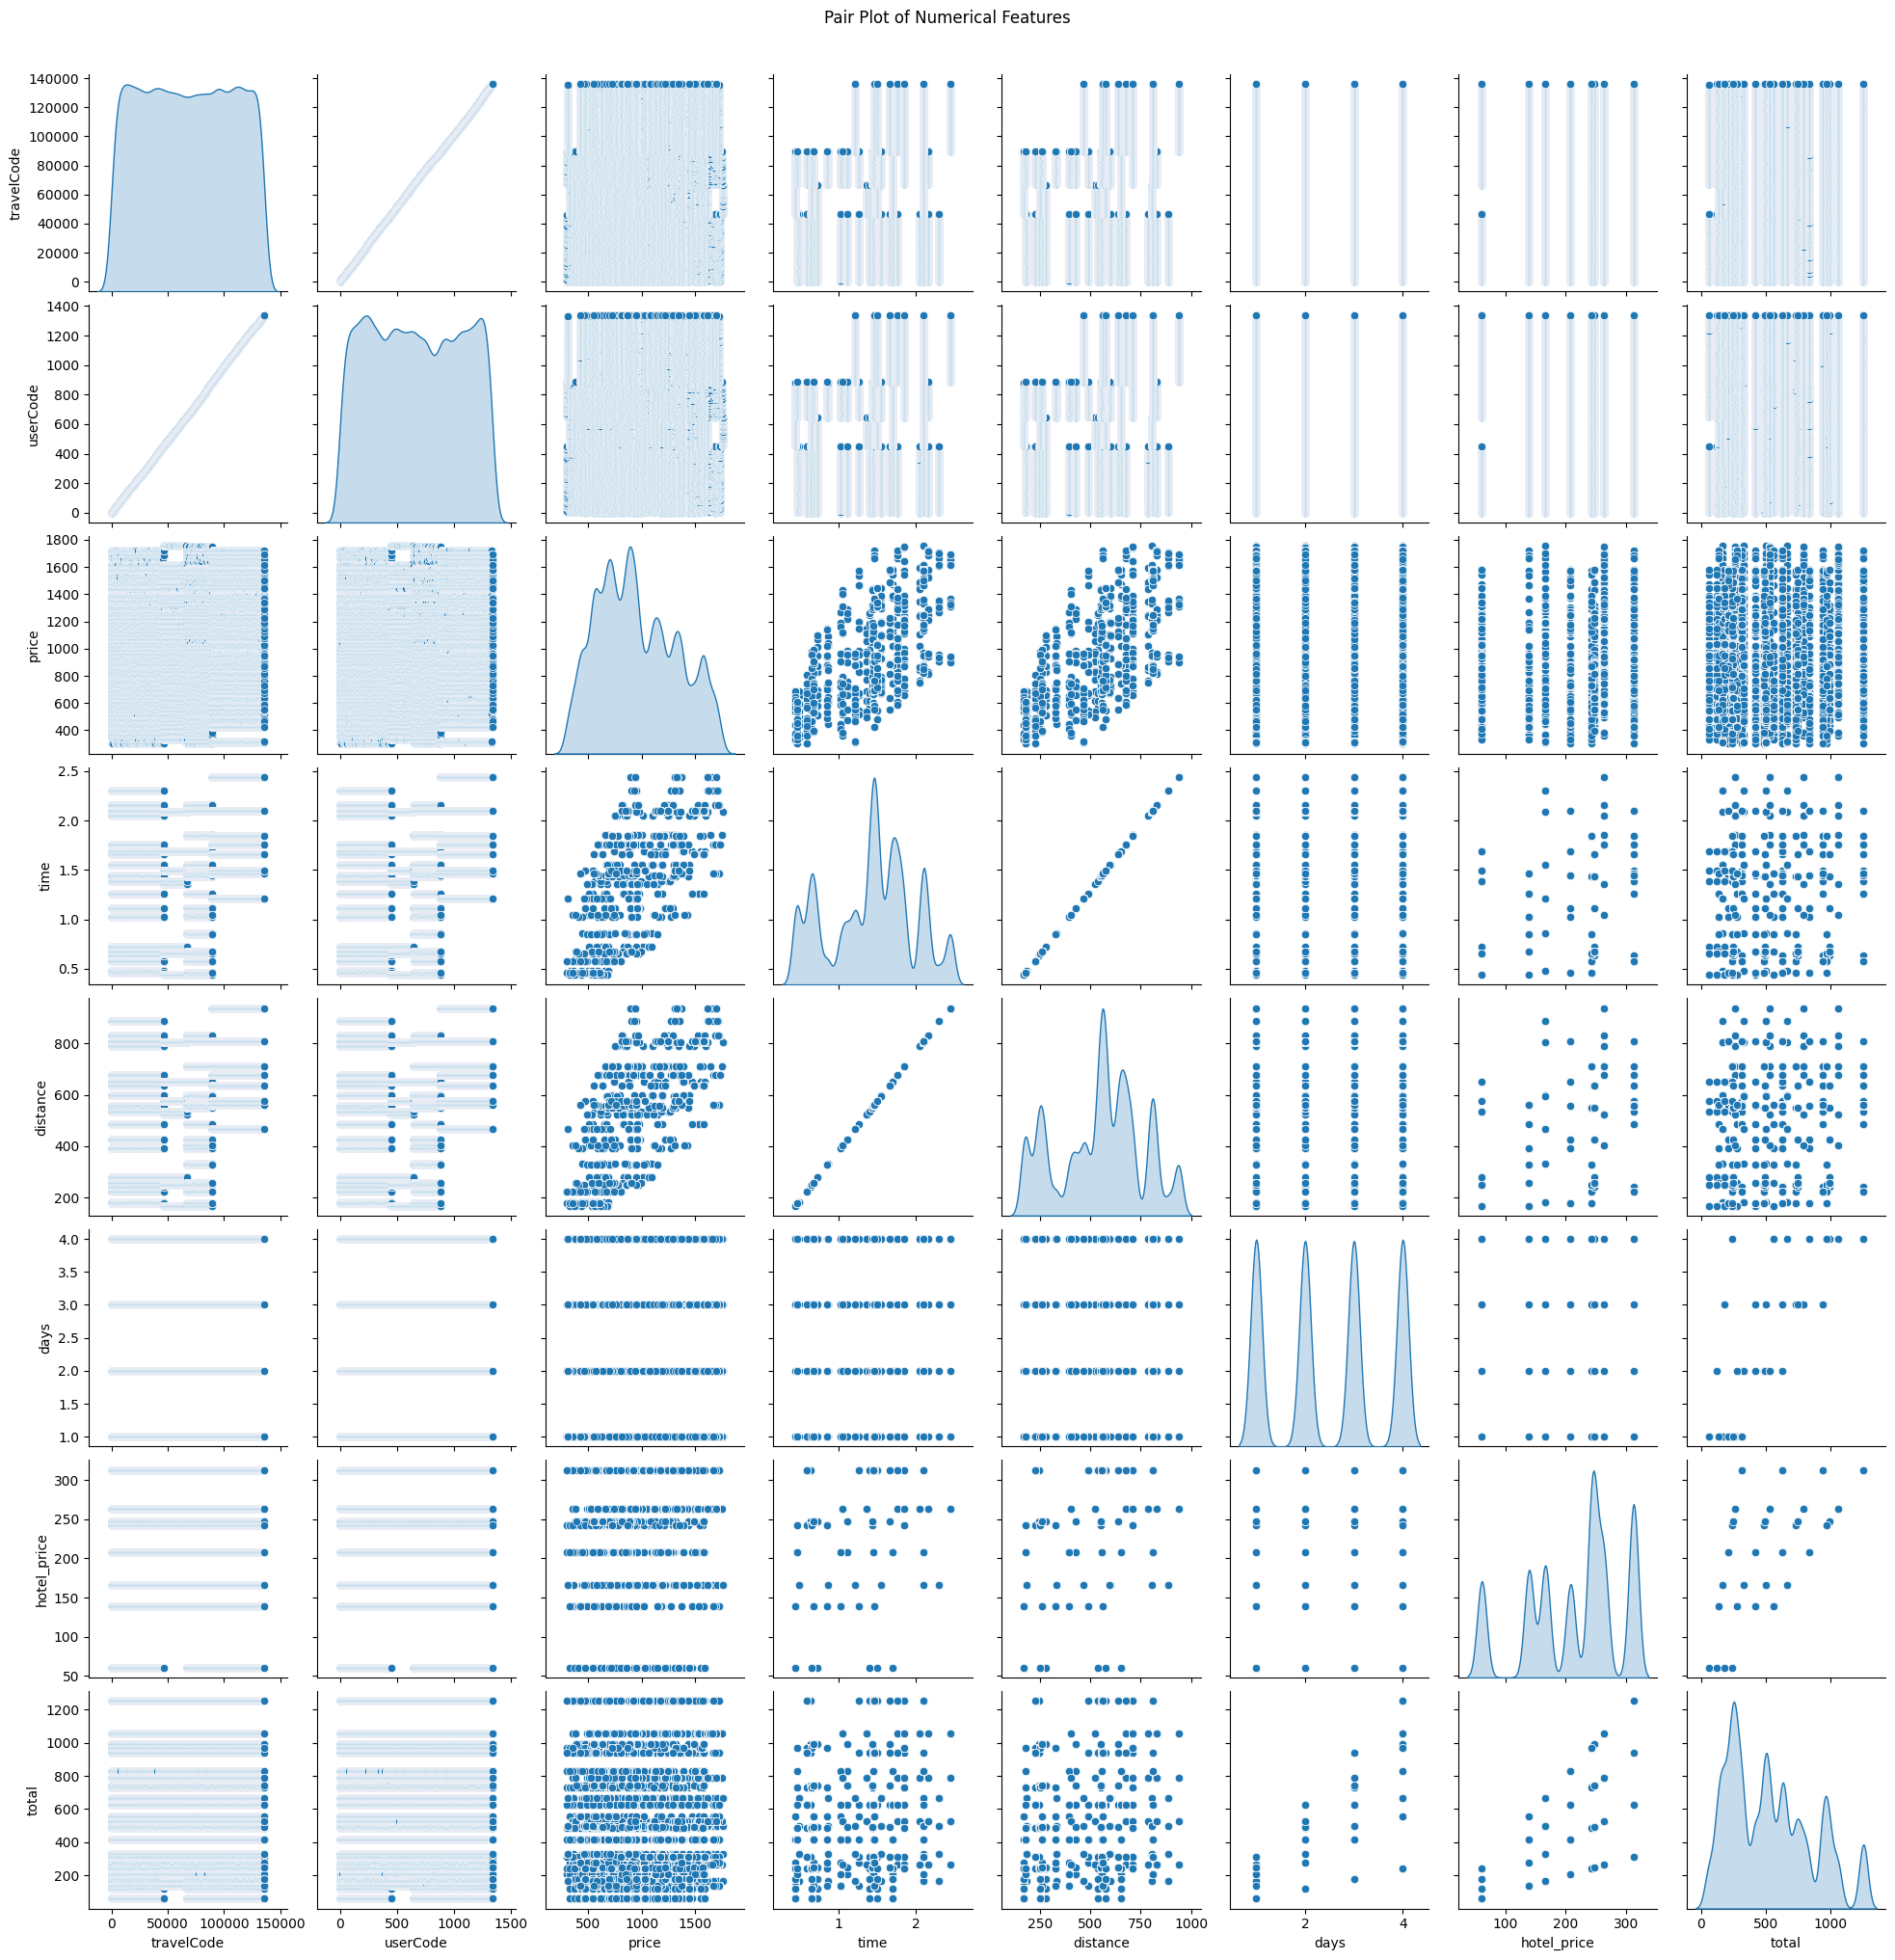

In [49]:
# Pair Plot visualization code
import seaborn as sns
import matplotlib.pyplot as plt
# Example columns

sns.pairplot(merged_data[numerical_cols], diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features', y=1.02)  # Add a title
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot helps visualize relationships between numerical features, detect correlations, spot outliers, and understand feature distributions—all essential for exploratory data analysis.

##### 2. What is/are the insight(s) found from the chart?

**Correlations:**
- Strong correlation likely exists between "Time" and another feature (possibly "Days" or "Age") due to the diagonal alignment in scatter plots.
- If "Amount" and "Balance" are present, they might show multicollinearity.

**Feature Distributions:**
- Features like "Age" and "Days" might have skewed distributions, requiring transformation.

**Outliers:**
- Some scatter plots show sparse points away from dense clusters, possibly in "Amount" or "Balance".

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **Null Hypothesis:** There is no significant difference in flight prices between different flight types.
- **Alternate Hypothesis:** There is a significant difference in flight prices between different flight types.

#### 2. Perform an appropriate statistical test.

In [50]:
# Step 1: Prepare the data
flight_types = flights['flightType'].unique()
price_by_flight_type = [flights[flights['flightType'] == flight_type]['price'] for flight_type in flight_types]

# Step 2: Perform ANOVA test
f_stat, p_value_1 = stats.f_oneway(*price_by_flight_type)

# Step 3: Set the significance level (alpha)
alpha = 0.05

# Step 4: Perform the hypothesis test
if p_value_1 < alpha:
    print("Reject Null Hypothesis: There is a significant difference in flight prices between different flight types.")
else:
    print("Fail to reject Null Hypothesis: There is no significant difference in flight prices between different flight types.")


Reject Null Hypothesis: There is a significant difference in flight prices between different flight types.


##### Which statistical test have you done to obtain P-Value?

Anova Test

##### Why did you choose the specific statistical test?

To determine if there are statistically significant differences between the means of three or more independent groups.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **Null Hypothesis:** There is no significant relationship between flight distance and flight price.
- **Alternate Hypothesis:** There is a significant relationship between flight distance and flight price.

#### 2. Perform an appropriate statistical test.

In [51]:
# Step 1: Prepare the data
X = flights['distance']
y = flights['price']

# Add a constant term to the independent variable (required for statsmodels)
X = sm.add_constant(X)

# Step 2: Fit the linear regression model
model = sm.OLS(y, X).fit()

# Step 3: Check p-value of the coefficient for 'distance'
p_value_2 = model.pvalues['distance']

# Step 4: Perform the hypothesis test
if p_value_2 < alpha:
    print("Reject Null Hypothesis: There is a significant relationship between flight distance and flight price.")
else:
    print("Fail to reject Null Hypothesis: There is no significant relationship between flight distance and flight price.")

Reject Null Hypothesis: There is a significant relationship between flight distance and flight price.


##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- **Null Hypothesis:** There is no significant difference in flight prices between different flight agencies.
- **Alternate Hypothesis:** There is a significant difference in flight prices between different flight agencies.

#### 2. Perform an appropriate statistical test.

In [52]:
# Step 1: Prepare the data
agencies = flights['agency'].unique()
price_by_agency = [flights[flights['agency'] == agency]['price'] for agency in agencies]

# Step 2: Perform ANOVA test
f_stat, p_value_3 = stats.f_oneway(*price_by_agency)

# Step 3: Perform the hypothesis test
if p_value_3 < alpha:
    print("Reject Null Hypothesis: There is a significant difference in flight prices between different flight agencies.")
else:
    print("Fail to reject Null Hypothesis: There is no significant difference in flight prices between different flight agencies.")

# Optional: Print the regression summary for Hypothesis 2
print(model.summary())

Reject Null Hypothesis: There is a significant difference in flight prices between different flight agencies.
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.412
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                 1.905e+05
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:53:46   Log-Likelihood:            -1.9157e+06
No. Observations:              271888   AIC:                         3.831e+06
Df Residuals:                  271886   BIC:                         3.831e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

##### Which statistical test have you done to obtain P-Value?

Anova Test

##### Why did you choose the specific statistical test?

To determine if there are statistically significant differences between the means of three or more independent groups.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [53]:
# Handling Missing Values & Missing Value Imputation
flights.isnull().sum()

,0
travelCode,0
userCode,0
from,0
to,0
flightType,0
price,0
time,0
distance,0
agency,0
date,0


In [54]:
hotel.isnull().sum()

,0
travelCode,0
userCode,0
hotel_name,0
place,0
days,0
hotel_price,0
total,0
hotel_date,0


In [55]:
user.isnull().sum()

,0
code,0
company,0
user_name,0
gender,0
age,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

There is no missing values in the dataset.

### 2. Handling Outliers

In [56]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [57]:
# Encode your categorical columns
flights['flightType'] = flights['flightType'].replace({'economic': 0, 'premium': 1, 'firstClass':3})

/tmp/ipykernel_2140/3538972923.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  flights['flightType'] = flights['flightType'].replace({'economic': 0, 'premium': 1, 'firstClass':3})


In [58]:
# Convert categorical variables to dummy/indicator variables
flights = pd.get_dummies(flights, columns=['from', 'to', 'flightType', 'agency'])

#### What all categorical encoding techniques have you used & why did you use those techniques?

- I have used ordinal encoding for flightType column because here we can see a perticular order of hireckly or there types

- I have also used one hot encoding for categorical column which does not follow any kind of hirecky

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [59]:
# Expand Contraction

#### 2. Lower Casing

In [60]:
# Lower Casing

#### 3. Removing Punctuations

In [61]:
#Removing Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [62]:
# Remove  URLs & Removing words and digits contain digits.

#### 5. Removing Stopwords & Removing White spaces

In [63]:
#Removing Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
#Rephrase Text

#### 7. Tokenization

In [ ]:
#Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [64]:
# Select your features wisely to avoid overfitting
X = flights.drop(columns=['travelCode', 'userCode', 'price', 'date'])
y = flights['price']

##### What all feature selection methods have you used  and why?

I have drop 'travelCode', 'userCode', 'price', 'date' this column because this columns will not have any impact on flight price predictions.

I have drop 'travelCode', 'userCode', 'price', 'date' this column because this columns will not have any impact on flight price predictions.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Splitting

In [65]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### What data splitting ratio have you used and why?

Answer Here.

### 7. Data Scaling

In [66]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##### Which method have you used to scale you data and why?

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [67]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Define models to benchmark
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "ElasticNet Regression": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

# Store metrics for each model
results = []

# Loop through each model
for name, model in models.items():
    print(f"Training: {name}")
    model.fit(X_train, y_train)                 # Train model
    y_pred = model.predict(X_test)             # Predict on test set

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store the results
    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R^2": r2
    })

# Convert to DataFrame for a clean summary
results_df = pd.DataFrame(results)

# Sort by best R² descending
results_df = results_df.sort_values(by="R^2", ascending=False).reset_index(drop=True)

# Show results
print("\nModel Performance Comparison:\n")
print(results_df)

Training: Linear Regression
Training: Ridge Regression
Training: Lasso Regression
Training: ElasticNet Regression
Training: Decision Tree
Training: Random Forest
Training: Gradient Boosting

Model Performance Comparison:

                   Model           MSE          RMSE           MAE       R^2
0          Decision Tree  8.736174e-23  9.346750e-12  7.143984e-12  1.000000
1          Random Forest  2.393966e-23  4.892817e-12  3.608902e-12  1.000000
2      Gradient Boosting  1.538426e+03  3.922277e+01  3.122293e+01  0.988325
3      Linear Regression  1.064031e+04  1.031519e+02  8.132138e+01  0.919250
4       Ridge Regression  1.064084e+04  1.031544e+02  8.130030e+01  0.919246
5       Lasso Regression  1.067024e+04  1.032968e+02  8.127446e+01  0.919023
6  ElasticNet Regression  2.033238e+04  1.425917e+02  1.157819e+02  0.845697


#### 2. Cross- Validation & Hyperparameter Tuning

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# --- Re-loading and preprocessing flights DataFrame to ensure it's defined ---
# Load Flights dataset (assuming it's already mounted as in cell 'MOVVLvG1mAtG')
flights = pd.read_csv("/content/drive/MyDrive/flights (1).csv")

# Encode flightType (as in cell 'gs8gXHRFsty9')
flights['flightType'] = flights['flightType'].replace({'economic': 0, 'premium': 1, 'firstClass':3})

# Convert categorical variables to dummy/indicator variables (as in cell 'b7M6o5Y6sxWW')
flights = pd.get_dummies(flights, columns=['from', 'to', 'flightType', 'agency'])
# ----------------------------------------------------------------------------------

# ===========================
# Create Features and Target
# ===========================

# Using the preprocessed 'flights' DataFrame for feature and target creation
X = flights.drop(columns=['travelCode', 'userCode', 'price', 'date'])
y = flights['price']

# ===========================
# Models
# ===========================

models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(max_iter=3000),

    "ElasticNet Regression": ElasticNet(max_iter=3000),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

# ===========================
# Cross Validation
# ===========================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "R2": "r2",
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

results = []

for name, model in models.items():

    print(f"Running: {name}")

    scores = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    mse = -scores["test_MSE"]
    mae = -scores["test_MAE"]
    r2 = scores["test_R2"]

    results.append({
        "Model": name,
        "R2 Mean": round(np.mean(r2),4),
        "R2 Std": round(np.std(r2),4),
        "MSE Mean": round(np.mean(mse),4),
        "RMSE Mean": round(np.sqrt(np.mean(mse)),4),
        "MAE Mean": round(np.mean(mae),4)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Mean",
    ascending=False
)

print("\nCross Validation Results\n")
print(results_df)

/tmp/ipykernel_14872/32070711.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  flights['flightType'] = flights['flightType'].replace({'economic': 0, 'premium': 1, 'firstClass':3})


Running: Linear Regression
Running: Ridge Regression
Running: Lasso Regression
Running: ElasticNet Regression
Running: Decision Tree
Running: Random Forest
Running: Gradient Boosting

Cross Validation Results

                   Model  R2 Mean  R2 Std    MSE Mean  RMSE Mean  MAE Mean
4          Decision Tree   1.0000  0.0000      0.0000     0.0000    0.0000
5          Random Forest   1.0000  0.0000      0.0000     0.0000    0.0000
6      Gradient Boosting   0.9881  0.0003   1559.0937    39.4854   31.5693
0      Linear Regression   0.9193  0.0004  10586.7505   102.8919   81.1290
1       Ridge Regression   0.9193  0.0004  10588.2240   102.8991   81.1100
2       Lasso Regression   0.9181  0.0004  10750.8334   103.6862   81.5305
3  ElasticNet Regression   0.7030  0.0003  38991.6885   197.4631  158.6750


target                      1.000000
distance                    0.641915
time                        0.641800
flightType_3                0.534265
flightType_0                0.520803
to_Florianopolis (SC)       0.325688
to_Sao Paulo (SP)           0.263119
agency_FlyingDrops          0.257471
to_Salvador (BH)            0.219528
to_Brasilia (DF)            0.187977
to_Campo Grande (MS)        0.122579
to_Aracaju (SE)             0.118577
to_Natal (RN)               0.111554
from_Salvador (BH)          0.098056
agency_CloudFy              0.091874
agency_Rainbow              0.090015
to_Rio de Janeiro (RJ)      0.078381
flightType_1                0.064745
from_Natal (RN)             0.039337
from_Florianopolis (SC)     0.033345
from_Recife (PE)            0.033014
from_Sao Paulo (SP)         0.026215
from_Brasilia (DF)          0.024236
from_Rio de Janeiro (RJ)    0.018969
to_Recife (PE)              0.006025
from_Aracaju (SE)           0.002707
from_Campo Grande (MS)      0.000297
N

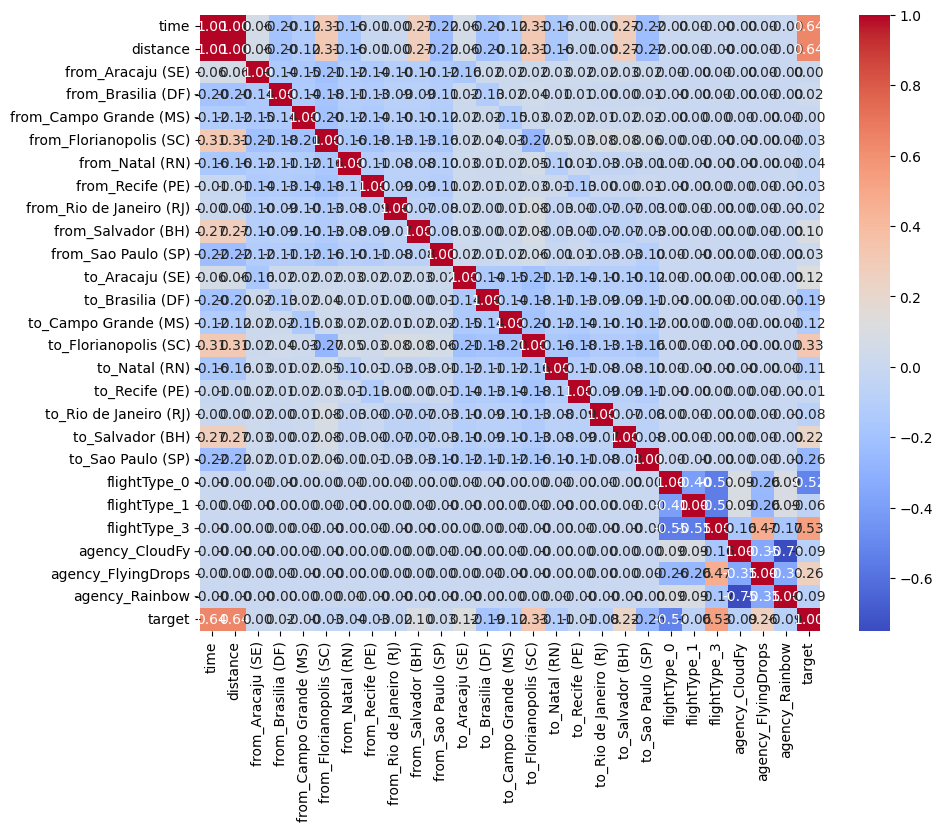

In [6]:
# Visualizing evaluation Metric Score chart
import seaborn as sns
import matplotlib.pyplot as plt

# Add target to DataFrame
df_with_target = pd.DataFrame(X)
df_with_target['target'] = y

# Compute correlations
corr_matrix = df_with_target.corr().abs().sort_values('target', ascending=False)

# Display correlations
print(corr_matrix['target'])

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_with_target.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()


### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [7]:
model = RandomForestRegressor()
model.fit(X, y)

importances = model.feature_importances_

# Pair with feature names
features = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
features = features.sort_values(by='Importance', ascending=False)

print(features)

                     Feature  Importance
22              flightType_3    0.296473
1                   distance    0.252444
0                       time    0.220724
21              flightType_1    0.070387
5    from_Florianopolis (SC)    0.048095
11           to_Aracaju (SE)    0.021309
14     to_Florianopolis (SC)    0.017783
10       from_Sao Paulo (SP)    0.011516
3         from_Brasilia (DF)    0.008918
19         to_Sao Paulo (SP)    0.007920
20              flightType_0    0.006569
15             to_Natal (RN)    0.006472
18          to_Salvador (BH)    0.005990
13      to_Campo Grande (MS)    0.003688
12          to_Brasilia (DF)    0.003687
4     from_Campo Grande (MS)    0.002915
6            from_Natal (RN)    0.002330
9         from_Salvador (BH)    0.002213
23            agency_CloudFy    0.002071
25            agency_Rainbow    0.002043
17    to_Rio de Janeiro (RJ)    0.001698
2          from_Aracaju (SE)    0.001666
16            to_Recife (PE)    0.000974
24        agency

### ML Model - 3

In [11]:
from sklearn.preprocessing import LabelEncoder
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import joblib
import pandas as pd # Import pandas if not already imported

# --- Re-loading and preprocessing user DataFrame to ensure it's defined ---
# Load Users dataset (assuming it's already mounted as in cell 'MOVVLvG1mAtG')
user = pd.read_csv("/content/drive/MyDrive/users (1).csv")

# Rename the columns as per cell 'dEqofyJno4O6'
user.rename(columns={'code':'userCode','name':'user_name'},inplace=True)
# ---------------------------------------------------------------------------

def train_model(df):
    # Encode gender labels
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df['gender'])

    # Load the sentence transformer model
    model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    # Corrected column name from 'name' to 'user_name'
    df['first_name'] =df['user_name'].apply(lambda x: x.split()[0])

    # Generate embeddings for names (using only first names)
    first_names = df['first_name'].tolist()
    embeddings = model.encode(first_names, show_progress_bar=True)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y, test_size=0.2, random_state=42, stratify=y
    )

    # Train a logistic regression classifier
    classifier = LogisticRegression(max_iter=1000, random_state=42)
    classifier.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = classifier.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Generate classification report
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)

    # Create visualization of embeddings
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(embeddings)

    # Save the model
    model_data = {
        'classifier': classifier,
        'label_encoder': label_encoder,
        'model_name': 'sentence-transformers/all-MiniLM-L6-v2'
    }
    joblib.dump(classifier, 'classifier.pkl')
    joblib.dump(label_encoder, 'label_encoder.pkl')
    joblib.dump(pca, 'pca.pkl')
    joblib.dump(model_data, 'name_gender_classifier.pkl')

    return {
        'accuracy': accuracy,
        'report': report,
        'label_encoder': label_encoder,
        'reduced_embeddings': reduced_embeddings,
        'genders': df['gender']
    }

train_model(user)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/42 [00:00<?, ?it/s]

{'accuracy': 0.6194029850746269,
 'report': {'female': {'precision': 0.6754385964912281,
   'recall': 0.8555555555555555,
   'f1-score': 0.7549019607843137,
   'support': 90.0},
  'male': {'precision': 0.64,
   'recall': 0.8888888888888888,
   'f1-score': 0.7441860465116279,
   'support': 90.0},
  'none': {'precision': 0.3103448275862069,
   'recall': 0.10227272727272728,
   'f1-score': 0.15384615384615385,
   'support': 88.0},
  'accuracy': 0.6194029850746269,
  'macro avg': {'precision': 0.5419278080258116,
   'recall': 0.6155723905723905,
   'f1-score': 0.5509780537140317,
   'support': 268.0},
  'weighted avg': {'precision': 0.5436560392231221,
   'recall': 0.6194029850746269,
   'f1-score': 0.5539417246085683,
   'support': 268.0}},
 'label_encoder': LabelEncoder(),
 'reduced_embeddings': array([[-0.19266626,  0.12930338],
        [-0.12357627,  0.08788295],
        [ 0.03590543,  0.01518294],
        ...,
        [-0.22999275, -0.06910625],
        [ 0.20537595,  0.10429148],
   

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Mean Absolute Error (MAE)

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Multiple regression models including Linear Regression, Decision Tree Regressor, and Random Forest Regressor were evaluated for flight price prediction. Random Forest Regressor was selected as the final model because it achieved the best performance metrics (higher R² and lower prediction errors), handled non-linear relationships effectively, reduced overfitting, and provided more robust predictions for the travel dataset.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

# joblib.dump(classifier, 'classifier.pkl')
# joblib.dump(label_encoder, 'label_encoder.pkl')
# joblib.dump(pca, 'pca.pkl')
# joblib.dump(model_data, 'name_gender_classifier.pkl')

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

The project successfully predicted flight prices using machine learning techniques. EDA and feature engineering improved data quality. Multiple regression algorithms were compared and Random Forest Regressor achieved the best performance. The model was further optimized using GridSearchCV. The complete project was later extended into an end-to-end MLOps workflow including Flask API, MLflow, Docker, Kubernetes, Airflow and Jenkins.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***